TASK 3 · Car Price Prediction with Machine Learning Objective: Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

In [454]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [455]:
df = pd.read_csv("car_prediction_data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Data Assessment

In [456]:
df.shape

(301, 9)

In [457]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [458]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [459]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [460]:
df.sample(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
155,Honda Activa 4G,2017,0.48,0.51,4300,Petrol,Individual,Automatic,0
184,Bajaj Pulsar 150,2008,0.25,0.75,26000,Petrol,Individual,Manual,1
212,creta,2016,11.25,13.60,22671,Petrol,Dealer,Manual,0
48,ertiga,2015,5.80,7.71,25870,Petrol,Dealer,Manual,0
252,brio,2015,5.40,6.82,31427,Petrol,Dealer,Automatic,0


Data preprocessing


In [461]:
#checking null values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [462]:
#checking duplicated values present in the dataset or not
df.duplicated().sum()

np.int64(2)

In [463]:
#removing duplicate values from the dataset
df.drop_duplicates(inplace=True)

In [464]:
#checking unique values in categorical columns
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
<StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


Feature Engineering

In [465]:
#predicting the age of the car based on the year of manufacture
current_year = 2026

df['Car_Age'] = current_year - df['Year']

In [466]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [ ]:
#extracting the brand name from the car name
df['Brand'] = df['Car_Name'].str.split().str[0]

In [468]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0,10,city
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0,11,brio
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0,17,city
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0,9,city
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0,10,brio


In [ ]:
#dropping unnecessary columns from the dataset
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

In [470]:
df

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,Diesel,Dealer,Manual,0,10,city
297,4.00,5.90,60000,Petrol,Dealer,Manual,0,11,brio
298,3.35,11.00,87934,Petrol,Dealer,Manual,0,17,city
299,11.50,12.50,9000,Diesel,Dealer,Manual,0,9,city



Exploratory Data Analysis (EDA)

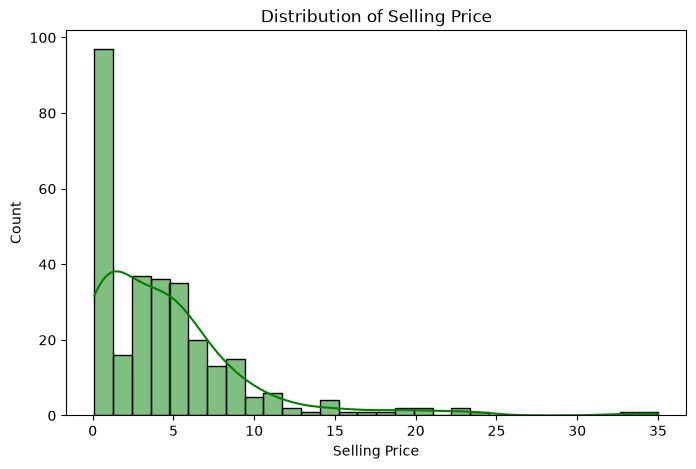

In [ ]:
#Distribution of Selling Price graph plot
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'],bins=30,kde=True,color='green')
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.show()

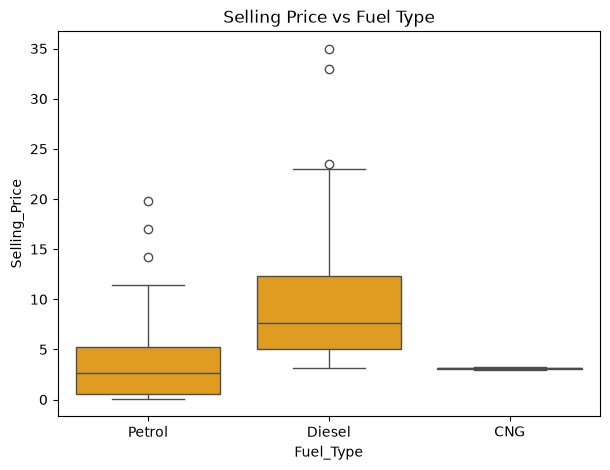

In [ ]:
#Boxplot of Selling Price vs Fuel Type plot
plt.figure(figsize=(7,5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, color='orange')
plt.title("Selling Price vs Fuel Type")
plt.show()

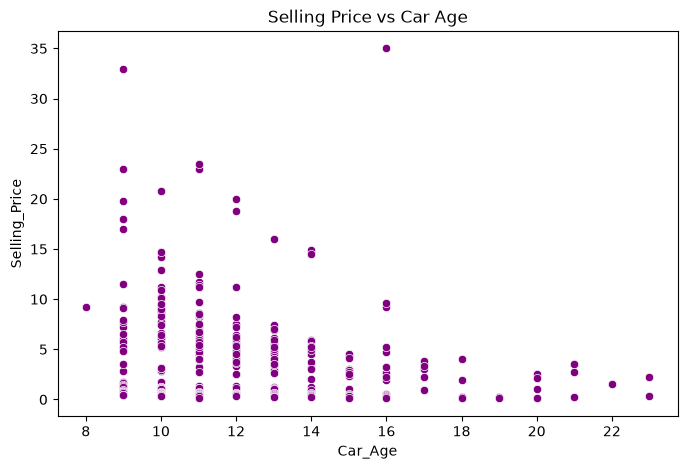

In [473]:
#Scatter Plot of Selling Price vs Car Age
plt.figure(figsize=(8,5))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df,color='purple')
plt.title("Selling Price vs Car Age")
plt.show()

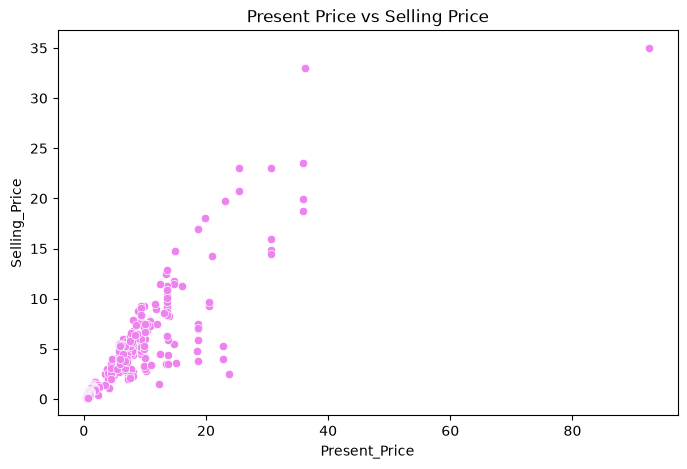

In [474]:
#Selling Price vs Present Price
plt.figure(figsize=(8,5))
sns.scatterplot(x='Present_Price',y='Selling_Price', data=df, color='violet')

plt.title("Present Price vs Selling Price")

plt.show()

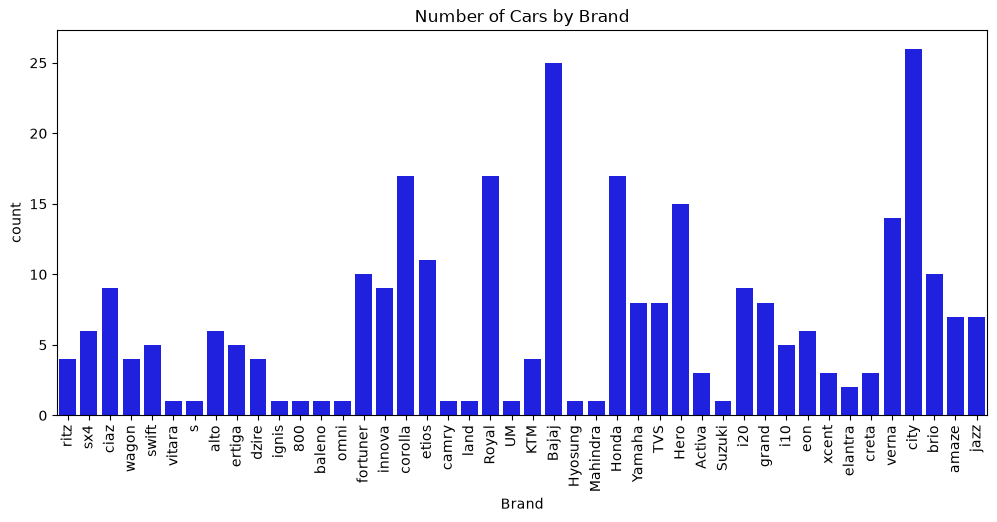

In [475]:
#Brand Count
plt.figure(figsize=(12,5))
sns.countplot(x='Brand',data=df,color='blue')
plt.xticks(rotation=90)
plt.title("Number of Cars by Brand")
plt.show()

we use label encoder for encoding the categorical values

In [493]:
le = LabelEncoder()

In [477]:
categorical_columns = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

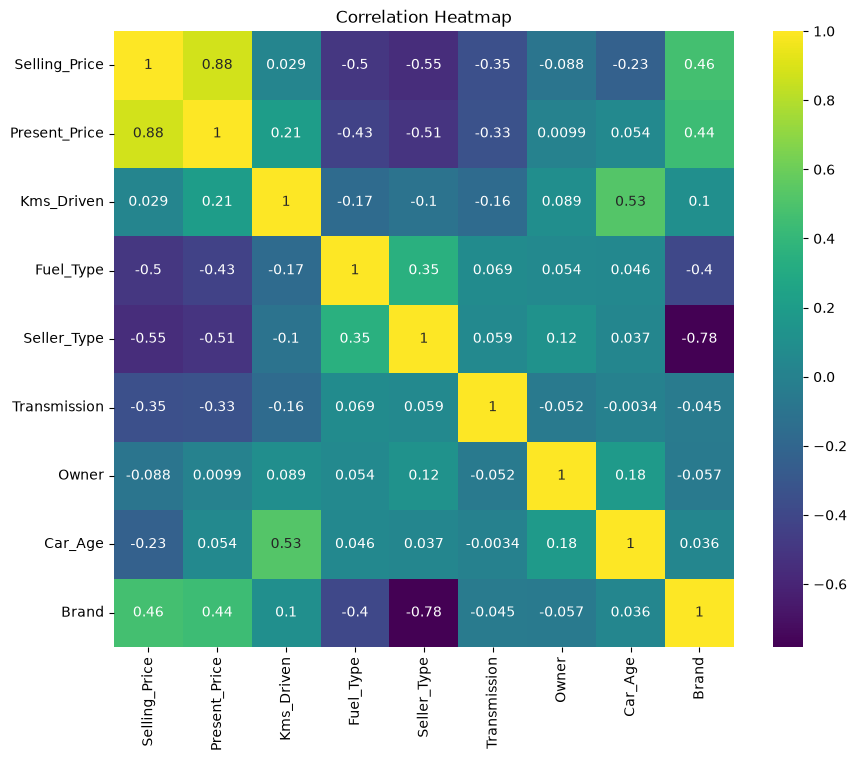

In [478]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='viridis')

plt.title("Correlation Heatmap")

plt.show()


from here machine learning part start

In [ ]:
#Splitting Features & Target values
X = df.drop('Selling_Price',axis=1)
y = df['Selling_Price']

In [480]:

# splitting the dataset into training and testing sets
X_train,X_test,y_train,y_test = train_test_split( X,  y, test_size=0.2, random_state=42
)

In [481]:
#training the Linear Regression model
model= LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.44,-0. ,-1.16,..., 0.74,-0.35, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Present_Price','Kms_Driven','Fuel_Type',...,'Owner','Car_Age','Brand']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.522
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [482]:
model_pred = model.predict(X_test)

In [ ]:
#metrics for evaluation of linear model
linear_mae = mean_absolute_error(y_test,model_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test,model_pred))
linear_r2 = r2_score(y_test,model_pred)

print("MAE :",linear_mae)
print("RMSE :",linear_rmse)
print("R2 Score :",linear_r2)

MAE : 1.5616707900367115
RMSE : 2.5982612704146377
R2 Score : 0.7380633630648481


In [484]:
# Training the Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [ ]:
gb_pred = gb_model.predict(X_test)

In [486]:
# Calculating metrics for Gradient Boosting Regressor
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("MAE :", gb_mae)
print("RMSE :", gb_rmse)
print("R2 Score :", gb_r2)

MAE : 1.1939864850865047
RMSE : 2.6989904989037092
R2 Score : 0.7173601987065646


In [487]:
# training the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [488]:
rf_pred = rf_model.predict(X_test)

In [489]:
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))
rf_r2 = r2_score(y_test,rf_pred)

print("MAE :",rf_mae)
print("RMSE :",rf_rmse)
print("R2 Score :",rf_r2)

MAE : 1.3161916666666673
RMSE : 3.226951935056776
R2 Score : 0.5959681509704974


In [490]:
#Model Comparison
results = pd.DataFrame({
    'Model':['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE':[linear_mae, rf_mae, gb_mae],
    'RMSE':[linear_rmse, rf_rmse, gb_rmse],
    'R2 Score':[linear_r2, rf_r2, gb_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.561671,2.598261,0.738063
1,Random Forest,1.316192,3.226952,0.595968
2,Gradient Boosting,1.193986,2.698990,0.717360


In [491]:
#Feature Importance for best performing (Best Model)
importance = pd.Series(
    model.coef_,
    index=X.columns
).sort_values(ascending=False)

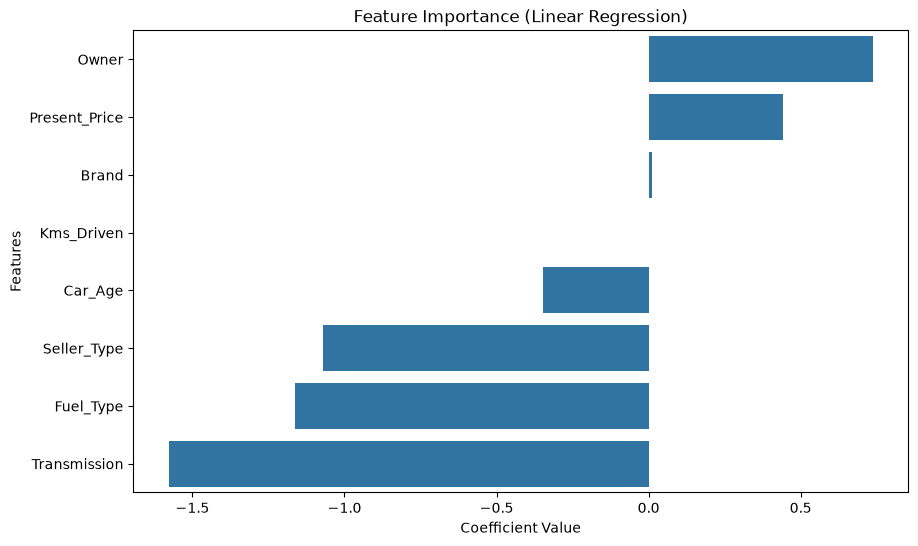

In [494]:
#Plot the Feature Importance
plt.figure(figsize=(10,6))
sns.barplot( x=importance.values, y=importance.index
)

plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()

# Interpretation of Feature Importance

-> Transmission has the largest negative coefficient, indicates that the encoded transmission type has a strong influence on the predicted selling price.

-> Fuel_Type and Seller_Type also have notable negative effects on the prediction.

-> Present_Price has a strong positive coefficient, meaning cars with a higher present market price tend to have a higher selling price.

-> Owner shows a positive influence in this model.

-> Car_Age has a negative coefficient, indicating that older cars generally sell for lower prices.

-> Kms_Driven and Brand have comparatively smaller effects in this fitted model.

## Conclusion

In this project, a machine learning model was developed to predict the selling price of used cars using features such as present price, kilometers driven, fuel type, seller type, transmission, ownership, brand, and car age. Data cleaning, feature engineering, and exploratory data analysis were performed before training three regression models: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor.

The models were evaluated using MAE, RMSE, and R² score. Among the three models, Linear Regression achieved the best overall performance with the highest R² score (0.7381) and the lowest RMSE (2.5983), indicating better predictive accuracy and model fit than Random Forest and Gradient Boosting on this dataset. Although Gradient Boosting produced the lowest MAE, Linear Regression provided the best balance of accuracy and generalization.

Feature importance analysis using Linear Regression coefficients showed that Present_Price, Transmission, Fuel_Type, Seller_Type, and Car_Age were among the most influential factors affecting the selling price of a used car. Overall, the project demonstrates that machine learning techniques can be effectively used to estimate used car prices and identify the key factors that influence vehicle valuation.